# Notebook 06: ResNet50 Baseline Training

## Objective

Train a pretrained ResNet50 model for multi-class pneumonia classification using the processed pediatric chest X-ray dataset.

## Workflow

1. Import Libraries
2. Configuration
3. Dataset Loading
4. Model Initialization
5. Training
6. Validation
7. Testing
8. Performance Evaluation
9. Model Saving

## Step 1: Import Required Libraries

## Import Required Libraries

In [1]:
# ============================================================
# Cell 1: Import Required Libraries
# Notebook 06 - ResNet50 Baseline Training
# ============================================================

# Standard Library
import copy
import random
import time
from pathlib import Path

# Data Processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress Bar
from tqdm.auto import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Pretrained Model
from torchvision.models import (
    resnet50,
    ResNet50_Weights
)

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_class_weight

# Plot Style
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

print("=" * 70)
print("Notebook 06 : ResNet50 Baseline Training")
print("Cell 1 : Required Libraries")
print(f"PyTorch Version : {torch.__version__}")
print("=" * 70)

Notebook 06 : ResNet50 Baseline Training
Cell 1 : Required Libraries
PyTorch Version : 2.13.0+cu126


In [2]:
# ============================================================
# Cell 2: Device Configuration
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("Cell 2 : Device Configuration")
print("-" * 70)

print(f"Selected Device : {DEVICE}")

if torch.cuda.is_available():

    print(f"GPU Name     : {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version : {torch.version.cuda}")

    gpu_memory = (
        torch.cuda.get_device_properties(0).total_memory
        / (1024 ** 3)
    )

    print(f"GPU Memory   : {gpu_memory:.2f} GB")

else:
    print("Running on CPU")

print("=" * 70)

Cell 2 : Device Configuration
----------------------------------------------------------------------
Selected Device : cuda
GPU Name     : NVIDIA GeForce RTX 3050
CUDA Version : 12.6
GPU Memory   : 8.00 GB


In [3]:
# ============================================================
# Cell 3: Random Seed Configuration
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("=" * 70)
print("Cell 3 : Random Seed Configuration")
print("-" * 70)
print(f"Random Seed : {SEED}")
print("Reproducibility : Enabled")
print("=" * 70)

Cell 3 : Random Seed Configuration
----------------------------------------------------------------------
Random Seed : 42
Reproducibility : Enabled


In [4]:
# ============================================================
# Cell 4: Hyperparameter Configuration
# ============================================================

# Experiment Information

MODEL_NAME = "ResNet50"
MODEL_ID = "resnet50"

MODEL_VERSION = "Baseline"

EXPERIMENT_NAME = "ResNet50_Baseline"

# Hyperparameters

IMAGE_SIZE = 224

BATCH_SIZE = 16

EPOCHS = 30

LEARNING_RATE = 1e-4

NUM_CLASSES = 3

NUM_WORKERS = 0

CLASS_NAMES = [
    "BACTERIA",
    "NORMAL",
    "VIRUS"
]

print("=" * 70)
print("Cell 4 : Hyperparameter Configuration")
print("-" * 70)

print(f"Model Name      : {MODEL_NAME}")
print(f"Image Size      : {IMAGE_SIZE}")
print(f"Batch Size      : {BATCH_SIZE}")
print(f"Epochs          : {EPOCHS}")
print(f"Learning Rate   : {LEARNING_RATE}")
print(f"Number Classes  : {NUM_CLASSES}")

print("=" * 70)

Cell 4 : Hyperparameter Configuration
----------------------------------------------------------------------
Model Name      : ResNet50
Image Size      : 224
Batch Size      : 16
Epochs          : 30
Learning Rate   : 0.0001
Number Classes  : 3


In [5]:
# ============================================================
# Cell 5: Project Directory Configuration
# ============================================================

# Project Directories

PROJECT_ROOT = Path(
    "/mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI"
)

DATASET_DIR = PROJECT_ROOT / "dataset" / "processed_dataset"

MODELS_DIR = PROJECT_ROOT / "models"

RESULTS_DIR = PROJECT_ROOT / "results"

FIGURES_DIR = PROJECT_ROOT / "figures"

LOGS_DIR = PROJECT_ROOT / "logs"

# Create Directories

for directory in [
    MODELS_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    LOGS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Output Files

BEST_MODEL_PATH = MODELS_DIR / f"{MODEL_ID}_best.pth"

CHECKPOINT_PATH = MODELS_DIR / f"{MODEL_ID}_checkpoint.pth"

HISTORY_PATH = RESULTS_DIR / f"{MODEL_ID}_training_history.csv"

CLASSIFICATION_REPORT_PATH = (
    RESULTS_DIR / f"{MODEL_ID}_classification_report.txt"
)

CONFUSION_MATRIX_PATH = (
    FIGURES_DIR / f"{MODEL_ID}_confusion_matrix.png"
)

LOSS_CURVE_PATH = (
    FIGURES_DIR / f"{MODEL_ID}_loss_curve.png"
)

ACCURACY_CURVE_PATH = (
    FIGURES_DIR / f"{MODEL_ID}_accuracy_curve.png"
)

print("=" * 70)
print("Cell 5 : Project Directory Configuration")
print("-" * 70)

print(f"Project Root : {PROJECT_ROOT}")
print(f"Dataset      : {DATASET_DIR}")
print(f"Models       : {MODELS_DIR}")
print(f"Results      : {RESULTS_DIR}")
print(f"Figures      : {FIGURES_DIR}")
print(f"Logs         : {LOGS_DIR}")

print("=" * 70)

Cell 5 : Project Directory Configuration
----------------------------------------------------------------------
Project Root : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI
Dataset      : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/dataset/processed_dataset
Models       : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models
Results      : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/results
Figures      : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/figures
Logs         : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/logs


## Data Preparation

In [6]:
# ============================================================
# Cell 6: Data Augmentation & Image Preprocessing
# ============================================================

# Training Data Transformation
train_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(degrees=10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),

    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])

# Validation Transformation
valid_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])

# Test Transformation
test_transform = valid_transform

print("=" * 70)
print("Cell 6 : Data Augmentation & Image Preprocessing")
print("-" * 70)
print(f"Training Image Size : {IMAGE_SIZE} x {IMAGE_SIZE}")
print("Training Transform  : Ready")
print("Validation Transform: Ready")
print("Test Transform      : Ready")
print("=" * 70)

Cell 6 : Data Augmentation & Image Preprocessing
----------------------------------------------------------------------
Training Image Size : 224 x 224
Training Transform  : Ready
Validation Transform: Ready
Test Transform      : Ready


In [7]:
# ============================================================
# Cell 7: Dataset Loading
# ============================================================

# -------------------------------
# Load Datasets
# -------------------------------

train_dataset = datasets.ImageFolder(
    root=DATASET_DIR / "train",
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    root=DATASET_DIR / "validation",
    transform=valid_transform
)

test_dataset = datasets.ImageFolder(
    root=DATASET_DIR / "test",
    transform=test_transform
)

# -------------------------------
# Dataset Information
# -------------------------------

print("=" * 70)
print("Cell 7 : Dataset Loading")
print("-" * 70)

print(f"Training Images   : {len(train_dataset)}")
print(f"Validation Images : {len(valid_dataset)}")
print(f"Test Images       : {len(test_dataset)}")

print("-" * 70)

print(f"Classes           : {train_dataset.classes}")
print(f"Number of Classes : {len(train_dataset.classes)}")

print("-" * 70)

print("Class to Index Mapping:")

for class_name, class_index in train_dataset.class_to_idx.items():
    print(f"  {class_name:<10} -> {class_index}")

print("=" * 70)

Cell 7 : Dataset Loading
----------------------------------------------------------------------
Training Images   : 4099
Validation Images : 878
Test Images       : 879
----------------------------------------------------------------------
Classes           : ['BACTERIA', 'NORMAL', 'VIRUS']
Number of Classes : 3
----------------------------------------------------------------------
Class to Index Mapping:
  BACTERIA   -> 0
  NORMAL     -> 1
  VIRUS      -> 2


## Data Loading

In [8]:
# ============================================================
# Cell 8: DataLoader Creation
# ============================================================

# Enable pin_memory only when using CUDA
PIN_MEMORY = torch.cuda.is_available()

# -------------------------------
# Training DataLoader
# -------------------------------

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)

# -------------------------------
# Validation DataLoader
# -------------------------------

valid_loader = DataLoader(
    dataset=valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)

# -------------------------------
# Test DataLoader
# -------------------------------

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)

# -------------------------------
# Display Information
# -------------------------------

print("=" * 70)
print("Cell 8 : DataLoader Creation")
print("-" * 70)

print(f"Training Batches   : {len(train_loader)}")
print(f"Validation Batches : {len(valid_loader)}")
print(f"Test Batches       : {len(test_loader)}")

print("-" * 70)

print(f"Batch Size         : {BATCH_SIZE}")
print(f"Number of Workers  : {NUM_WORKERS}")
print(f"Pin Memory         : {PIN_MEMORY}")

print("=" * 70)

Cell 8 : DataLoader Creation
----------------------------------------------------------------------
Training Batches   : 257
Validation Batches : 55
Test Batches       : 55
----------------------------------------------------------------------
Batch Size         : 16
Number of Workers  : 0
Pin Memory         : True


In [9]:
# ============================================================
# Cell 8: DataLoader Creation
# ============================================================

# Enable pin_memory only when using CUDA
PIN_MEMORY = DEVICE.type == "cuda"

# -------------------------------
# Training DataLoader
# -------------------------------

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)

# -------------------------------
# Validation DataLoader
# -------------------------------

valid_loader = DataLoader(
    dataset=valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)

# -------------------------------
# Test DataLoader
# -------------------------------

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)

# -------------------------------
# Display Information
# -------------------------------

print("=" * 70)
print("Cell 8 : DataLoader Creation")
print("-" * 70)

print(f"Training Batches   : {len(train_loader)}")
print(f"Validation Batches : {len(valid_loader)}")
print(f"Test Batches       : {len(test_loader)}")

print("-" * 70)

print(f"Batch Size         : {BATCH_SIZE}")
print(f"Number of Workers  : {NUM_WORKERS}")
print(f"Pin Memory         : {PIN_MEMORY}")

print("=" * 70)

Cell 8 : DataLoader Creation
----------------------------------------------------------------------
Training Batches   : 257
Validation Batches : 55
Test Batches       : 55
----------------------------------------------------------------------
Batch Size         : 16
Number of Workers  : 0
Pin Memory         : True


## Dataset Verification

Cell 9 : Dataset Visualization
----------------------------------------------------------------------
Batch Image Shape : torch.Size([16, 3, 224, 224])
Batch Label Shape : torch.Size([16])


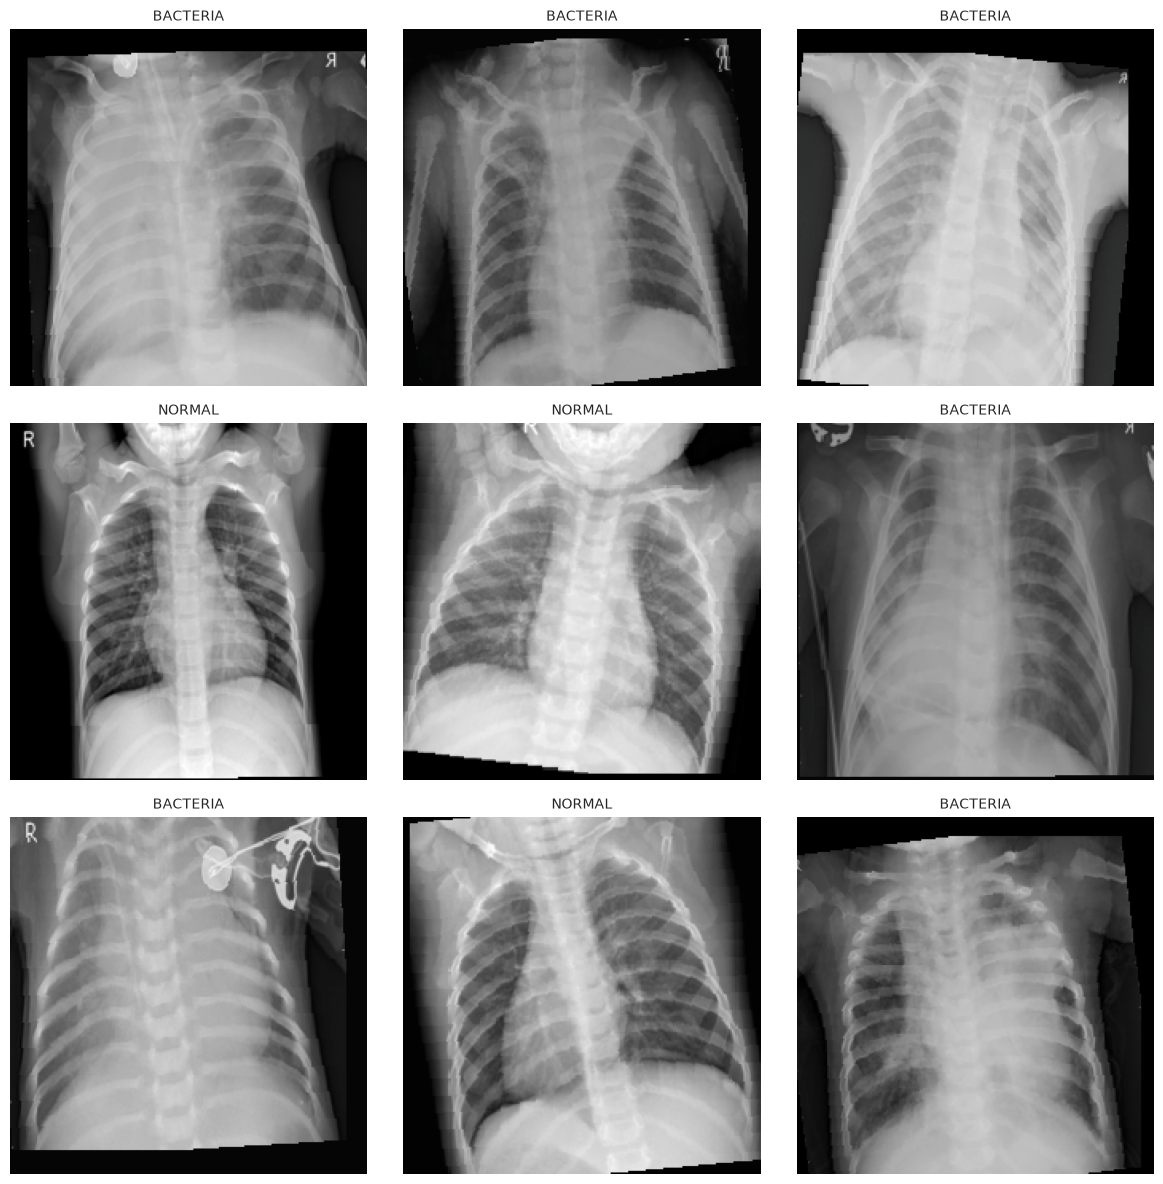

In [10]:
# ============================================================
# Cell 9: Dataset Visualization
# ============================================================

# Get one batch of training images
images, labels = next(iter(train_loader))

# Display batch information
print("=" * 70)
print("Cell 9 : Dataset Visualization")
print("-" * 70)

print(f"Batch Image Shape : {images.shape}")
print(f"Batch Label Shape : {labels.shape}")

print("=" * 70)

# ImageNet Normalization Statistics
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Display 9 sample images
plt.figure(figsize=(12, 12))

for i in range(9):

    image = images[i].permute(1, 2, 0).cpu().numpy()

    # De-normalize image
    image = (image * std) + mean
    image = np.clip(image, 0, 1)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(CLASS_NAMES[labels[i].item()], fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Dataset Analysis

Cell 10 : Class Distribution
----------------------------------------------------------------------
          Train  Validation  Test
BACTERIA   1946         417   417
NORMAL     1108         237   238
VIRUS      1045         224   224


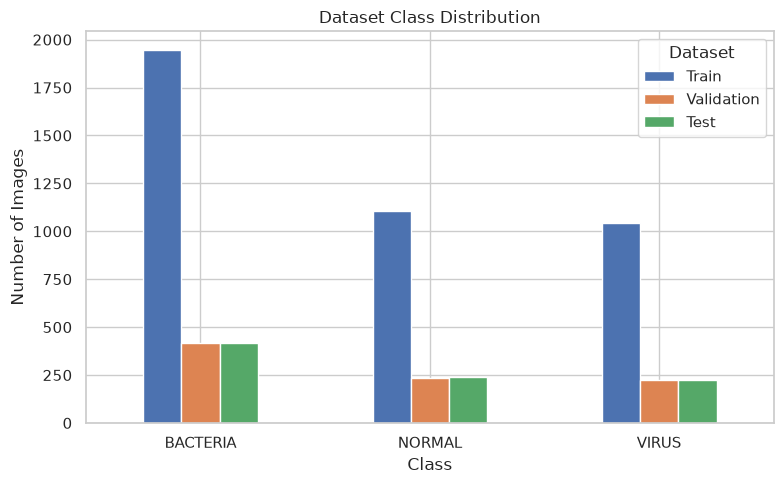

In [11]:
# ============================================================
# Cell 10: Class Distribution Visualization
# ============================================================

# -------------------------------
# Count Images in Each Dataset
# -------------------------------

train_counts = pd.Series(train_dataset.targets).value_counts().sort_index()
valid_counts = pd.Series(valid_dataset.targets).value_counts().sort_index()
test_counts = pd.Series(test_dataset.targets).value_counts().sort_index()

distribution_df = pd.DataFrame({
    "Train": train_counts.values,
    "Validation": valid_counts.values,
    "Test": test_counts.values
}, index=CLASS_NAMES)

# -------------------------------
# Display Distribution Table
# -------------------------------

print("=" * 70)
print("Cell 10 : Class Distribution")
print("-" * 70)

print(distribution_df)

print("=" * 70)

# -------------------------------
# Plot Class Distribution
# -------------------------------

ax = distribution_df.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=0)

plt.legend(title="Dataset")

plt.tight_layout()

plt.show()

## Training Preparation

In [12]:
# ============================================================
# Cell 11: Class Weight Computation
# ============================================================

# -------------------------------
# Compute Class Weights
# -------------------------------

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_dataset.targets),
    y=train_dataset.targets
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

# -------------------------------
# Display Class Weights
# -------------------------------

print("=" * 70)
print("Cell 11 : Class Weight Computation")
print("-" * 70)

for class_name, weight in zip(CLASS_NAMES, class_weights):
    print(f"{class_name:<10}: {weight.item():.4f}")

print("=" * 70)

Cell 11 : Class Weight Computation
----------------------------------------------------------------------
BACTERIA  : 0.7021
NORMAL    : 1.2332
VIRUS     : 1.3075


## Model Development

In [13]:
# ============================================================
# Cell 12: ResNet50 Model Initialization
# ============================================================

# -------------------------------
# Load Pretrained ResNet50
# -------------------------------

model = resnet50(
    weights=ResNet50_Weights.DEFAULT
)

# -------------------------------
# Replace Classification Head
# -------------------------------

in_features = model.fc.in_features

model.fc = nn.Linear(
    in_features=in_features,
    out_features=NUM_CLASSES
)

# -------------------------------
# Move Model to Device
# -------------------------------

model = model.to(DEVICE)

# -------------------------------
# Count Parameters
# -------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

# -------------------------------
# Display Information
# -------------------------------

print("=" * 70)
print("Cell 12 : ResNet50 Model Initialization")
print("-" * 70)

print(f"Model Name           : {MODEL_NAME}")
print(f"Pretrained Weights   : ImageNet")
print(f"Input Features       : {in_features}")
print(f"Output Classes       : {NUM_CLASSES}")

print("-" * 70)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

print("-" * 70)

print(f"Model Device         : {DEVICE}")

print("=" * 70)

Cell 12 : ResNet50 Model Initialization
----------------------------------------------------------------------
Model Name           : ResNet50
Pretrained Weights   : ImageNet
Input Features       : 2048
Output Classes       : 3
----------------------------------------------------------------------
Total Parameters     : 23,514,179
Trainable Parameters : 23,514,179
----------------------------------------------------------------------
Model Device         : cuda


## Model Training Configuration

In [14]:
# ============================================================
# Cell 13: Loss Function, Optimizer & Learning Rate Scheduler
# ============================================================

# -------------------------------
# Loss Function
# -------------------------------

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# -------------------------------
# Optimizer
# -------------------------------

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

# -------------------------------
# Learning Rate Scheduler
# -------------------------------

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=4,
    threshold=1e-3,
    min_lr=1e-6
)

# -------------------------------
# Display Configuration
# -------------------------------

print("=" * 70)
print("Cell 13 : Training Configuration")
print("-" * 70)

print(f"Loss Function      : {criterion.__class__.__name__}")
print(f"Optimizer          : {optimizer.__class__.__name__}")
print(f"Learning Rate      : {LEARNING_RATE}")
print(f"Scheduler          : ReduceLROnPlateau")
print(f"LR Reduction       : x0.5")
print(f"Scheduler Patience : 3")
print(f"Minimum LR         : 1e-6")

print("=" * 70)

Cell 13 : Training Configuration
----------------------------------------------------------------------
Loss Function      : CrossEntropyLoss
Optimizer          : AdamW
Learning Rate      : 0.0001
Scheduler          : ReduceLROnPlateau
LR Reduction       : x0.5
Scheduler Patience : 3
Minimum LR         : 1e-6


## Model Training

In [15]:
# ============================================================
# Cell 14: Training Function
# ============================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    progress_bar = tqdm(
        dataloader,
        desc="Training",
        leave=False
    )

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        # Forward Pass
        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        # Backward Pass
        loss.backward()

        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        _, predictions = torch.max(outputs, dim=1)

        correct_predictions += (predictions == labels).sum().item()

        total_samples += labels.size(0)

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = running_loss / total_samples

    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy
print("=" * 70)
print("Cell 14 : Training Function Created Successfully")
print("=" * 70)

Cell 14 : Training Function Created Successfully


In [16]:
# ============================================================
# Cell 15: Validation Function
# ============================================================

def validate_one_epoch(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():

        progress_bar = tqdm(
            dataloader,
            desc="Validation",
            leave=False
        )

        for images, labels in progress_bar:

            images = images.to(device)
            labels = labels.to(device)

            # Forward Pass
            outputs = model(images)

            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * images.size(0)

            _, predictions = torch.max(outputs, dim=1)

            correct_predictions += (predictions == labels).sum().item()

            total_samples += labels.size(0)

            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}"
            )

    epoch_loss = running_loss / total_samples

    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy


print("=" * 70)
print("Cell 15 : Validation Function Created Successfully")
print("=" * 70)

Cell 15 : Validation Function Created Successfully


In [17]:
# ============================================================
# Cell 16: Training Initialization
# ============================================================

# -------------------------------
# Training History
# -------------------------------

history = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "valid_loss": [],
    "valid_accuracy": [],
    "learning_rate": []
}

# -------------------------------
# Best Model Tracking
# -------------------------------

best_val_accuracy = 0.0
best_epoch = 0

# -------------------------------
# Early Stopping
# -------------------------------

early_stopping_patience = 7
early_stopping_counter = 0

# -------------------------------
# Training Timer
# -------------------------------

start_time = time.time()

print("=" * 70)
print("Cell 16 : Training Initialization")
print("-" * 70)
print(f"Best Validation Accuracy : {best_val_accuracy:.4f}")
print(f"Early Stopping Patience  : {early_stopping_patience}")
print(f"Training History         : Initialized")
print("=" * 70)

Cell 16 : Training Initialization
----------------------------------------------------------------------
Best Validation Accuracy : 0.0000
Early Stopping Patience  : 7
Training History         : Initialized


In [18]:
# ============================================================
# Cell 17: Model Training Loop
# ============================================================

print("=" * 70)
print(f"Training {MODEL_NAME}")
print("=" * 70)

for epoch in range(EPOCHS):

    epoch_start_time = time.time()

    print(f"\nEpoch [{epoch + 1}/{EPOCHS}]")
    print("-" * 70)

    # --------------------------------------------------
    # Training
    # --------------------------------------------------

    train_loss, train_accuracy = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE
    )

    # --------------------------------------------------
    # Validation
    # --------------------------------------------------

    valid_loss, valid_accuracy = validate_one_epoch(
        model=model,
        dataloader=valid_loader,
        criterion=criterion,
        device=DEVICE
    )

    # --------------------------------------------------
    # Learning Rate Scheduler
    # --------------------------------------------------

    scheduler.step(valid_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    # --------------------------------------------------
    # Save Training History
    # --------------------------------------------------

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["valid_loss"].append(valid_loss)
    history["valid_accuracy"].append(valid_accuracy)
    history["learning_rate"].append(current_lr)

    # --------------------------------------------------
    # Save Best Model
    # --------------------------------------------------

    is_best = valid_accuracy > best_val_accuracy

    if is_best:

        best_val_accuracy = valid_accuracy
        best_epoch = epoch + 1
        early_stopping_counter = 0

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print("✅ Best model updated.")

    else:

        early_stopping_counter += 1

    # --------------------------------------------------
    # Save Checkpoint
    # --------------------------------------------------

    checkpoint = {
        "epoch": epoch + 1,
        "model_name": MODEL_NAME,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_epoch": best_epoch,
        "best_val_accuracy": best_val_accuracy,
        "history": history
    }

    torch.save(
        checkpoint,
        CHECKPOINT_PATH
    )

    # --------------------------------------------------
    # Epoch Time
    # --------------------------------------------------

    epoch_time = time.time() - epoch_start_time

    # --------------------------------------------------
    # Display Epoch Results
    # --------------------------------------------------

    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Train Accuracy  : {train_accuracy:.4f}")

    print(f"Valid Loss      : {valid_loss:.4f}")
    print(f"Valid Accuracy  : {valid_accuracy:.4f}")

    print(f"Learning Rate   : {current_lr:.6f}")
    print(f"Epoch Time      : {epoch_time:.2f} sec")

    print(f"Best Accuracy   : {best_val_accuracy:.4f}")

    # --------------------------------------------------
    # Early Stopping
    # --------------------------------------------------

    if early_stopping_counter >= early_stopping_patience:

        print("\n🛑 Early Stopping Triggered")
        break

# ============================================================
# Training Completed
# ============================================================

training_time = time.time() - start_time

print("\n" + "=" * 70)
print("Training Completed")
print("-" * 70)

print(f"Best Epoch              : {best_epoch}")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Total Training Time     : {training_time / 60:.2f} minutes")

print("=" * 70)

Training ResNet50

Epoch [1/30]
----------------------------------------------------------------------


Training:   0%|          | 0/257 [00:00<?, ?it/s]

Validation:   0%|          | 0/55 [00:00<?, ?it/s]

✅ Best model updated.
Train Loss      : 0.6074
Train Accuracy  : 0.7382
Valid Loss      : 0.4910
Valid Accuracy  : 0.7973
Learning Rate   : 0.000100
Epoch Time      : 214.93 sec
Best Accuracy   : 0.7973

Epoch [2/30]
----------------------------------------------------------------------


Training:   0%|          | 0/257 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/55 [00:00<?, ?it/s]

Train Loss      : 0.0367
Train Accuracy  : 0.9890
Valid Loss      : 0.7186
Valid Accuracy  : 0.8371
Learning Rate   : 0.000003
Epoch Time      : 122.95 sec
Best Accuracy   : 0.8405

Epoch [30/30]
----------------------------------------------------------------------


Training:   0%|          | 0/257 [00:00<?, ?it/s]

Validation:   0%|          | 0/55 [00:00<?, ?it/s]

Train Loss      : 0.0388
Train Accuracy  : 0.9876
Valid Loss      : 0.7275
Valid Accuracy  : 0.8349
Learning Rate   : 0.000003
Epoch Time      : 116.58 sec
Best Accuracy   : 0.8405

Training Completed
----------------------------------------------------------------------
Best Epoch              : 25
Best Validation Accuracy: 0.8405
Total Training Time     : 61.64 minutes


# Model Evaluation

In [23]:
# ============================================================
# Cell 18: Load Best Model
# ============================================================

# -------------------------------
# Load Best Model Weights
# -------------------------------

state_dict = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(state_dict)

model.to(DEVICE)

model.eval()

# -------------------------------
# Display Information
# -------------------------------

print("=" * 70)
print("Cell 18 : Best Model Loaded")
print("-" * 70)

print(f"Model Name            : {MODEL_NAME}")
print(f"Best Model Path       : {BEST_MODEL_PATH}")
print(f"Best Validation Acc   : {best_val_accuracy:.4f}")
print(f"Best Epoch            : {best_epoch}")
print(f"Model Device          : {DEVICE}")

print("=" * 70)

Cell 18 : Best Model Loaded
----------------------------------------------------------------------
Model Name            : ResNet50
Best Model Path       : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/resnet50_best.pth
Best Validation Acc   : 0.8405
Best Epoch            : 25
Model Device          : cuda


## Test Set Evaluation

In [24]:
# ============================================================
# Cell 19: Test Set Evaluation
# ============================================================

model.eval()

test_loss = 0.0
correct_predictions = 0
total_samples = 0

all_predictions = []
all_labels = []
all_probabilities = []

with torch.no_grad():

    progress_bar = tqdm(
        test_loader,
        desc="Testing",
        leave=False
    )

    for images, labels in progress_bar:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # Forward Pass
        outputs = model(images)

        loss = criterion(outputs, labels)

        probabilities = torch.softmax(outputs, dim=1)

        _, predictions = torch.max(outputs, dim=1)

        # Statistics
        test_loss += loss.item() * images.size(0)

        correct_predictions += (
            predictions == labels
        ).sum().item()

        total_samples += labels.size(0)

        # Store Results
        all_predictions.extend(
            predictions.cpu().numpy().tolist()
        )

        all_labels.extend(
            labels.cpu().numpy().tolist()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy().tolist()
        )

# ============================================================
# Final Metrics
# ============================================================

test_loss /= total_samples
test_accuracy = correct_predictions / total_samples

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
all_probabilities = np.array(all_probabilities)

# ============================================================
# Display Results
# ============================================================

print("=" * 70)
print("Cell 19 : Test Set Evaluation")
print("-" * 70)

print(f"Test Samples      : {total_samples}")
print(f"Test Loss         : {test_loss:.4f}")
print(f"Test Accuracy     : {test_accuracy:.4f}")

print("-" * 70)
print(f"Prediction Shape  : {all_predictions.shape}")
print(f"Label Shape       : {all_labels.shape}")
print(f"Probability Shape : {all_probabilities.shape}")

print("=" * 70)

Testing:   0%|          | 0/55 [00:00<?, ?it/s]

Cell 19 : Test Set Evaluation
----------------------------------------------------------------------
Test Samples      : 879
Test Loss         : 0.5904
Test Accuracy     : 0.8498
----------------------------------------------------------------------
Prediction Shape  : (879,)
Label Shape       : (879,)
Probability Shape : (879, 3)


## Save Training History

In [25]:
# ============================================================
# Cell 20: Save Training History
# ============================================================

# -------------------------------
# Convert History to DataFrame
# -------------------------------

history_df = pd.DataFrame(history)

# -------------------------------
# Save CSV
# -------------------------------

history_df.to_csv(
    HISTORY_PATH,
    index=False
)

# -------------------------------
# Display Information
# -------------------------------

print("=" * 70)
print("Cell 20 : Training History Saved")
print("-" * 70)

print(f"File Path : {HISTORY_PATH}")
print(f"Total Epochs Saved : {len(history_df)}")

print("=" * 70)

# Display First 5 Rows
display(history_df.head())

Cell 20 : Training History Saved
----------------------------------------------------------------------
File Path : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/results/resnet50_training_history.csv
Total Epochs Saved : 30


,epoch,train_loss,train_accuracy,valid_loss,valid_accuracy,learning_rate
0,1,0.607406,0.738229,0.491016,0.797267,0.0001
1,2,0.463955,0.791900,0.474421,0.823462,0.0001
2,3,0.429620,0.813369,0.452808,0.814351,0.0001
3,4,0.400170,0.826299,0.463482,0.806378,0.0001
4,5,0.362975,0.841425,0.478149,0.791572,0.0001


## Classification Report

In [26]:
# ============================================================
# Cell 21: Classification Report
# ============================================================

# -------------------------------
# Generate Classification Report
# -------------------------------

report = classification_report(
    all_labels,
    all_predictions,
    target_names=CLASS_NAMES,
    digits=4
)

# -------------------------------
# Save Report
# -------------------------------

with open(CLASSIFICATION_REPORT_PATH, "w") as file:
    file.write(report)

# -------------------------------
# Display Report
# -------------------------------

print("=" * 70)
print("Cell 21 : Classification Report")
print("-" * 70)

print(report)

print("-" * 70)
print(f"Saved To : {CLASSIFICATION_REPORT_PATH}")

print("=" * 70)

Cell 21 : Classification Report
----------------------------------------------------------------------
              precision    recall  f1-score   support

    BACTERIA     0.8763    0.8321    0.8536       417
      NORMAL     0.9512    0.9832    0.9669       238
       VIRUS     0.7004    0.7411    0.7202       224

    accuracy                         0.8498       879
   macro avg     0.8426    0.8521    0.8469       879
weighted avg     0.8517    0.8498    0.8503       879

----------------------------------------------------------------------
Saved To : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/results/resnet50_classification_report.txt


## Confusion Matrix

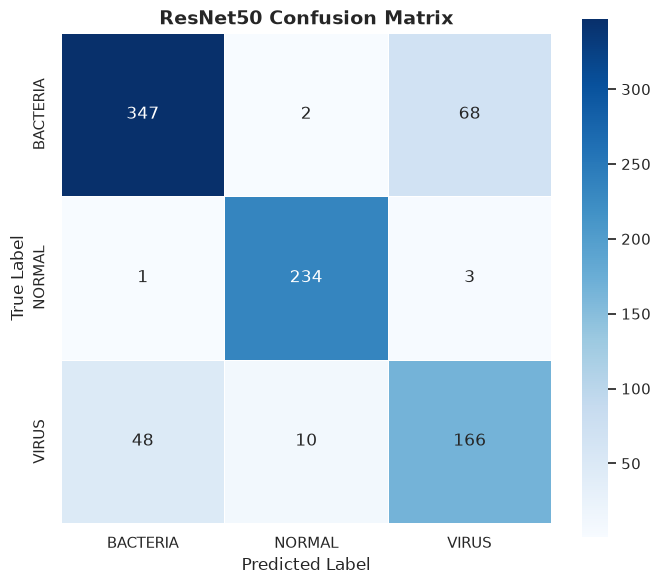

Cell 22 : Confusion Matrix Saved
----------------------------------------------------------------------
Saved To : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/figures/resnet50_confusion_matrix.png


In [27]:
# ============================================================
# Cell 22: Confusion Matrix
# ============================================================

# -------------------------------
# Compute Confusion Matrix
# -------------------------------

cm = confusion_matrix(
    all_labels,
    all_predictions
)

# -------------------------------
# Plot
# -------------------------------

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar=True,
    linewidths=0.5,
    square=True
)

plt.title(
    f"{MODEL_NAME} Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.tight_layout()

# -------------------------------
# Save Figure
# -------------------------------

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("Cell 22 : Confusion Matrix Saved")
print("-" * 70)
print(f"Saved To : {CONFUSION_MATRIX_PATH}")
print("=" * 70)

## Training Accuracy and Loss Curves

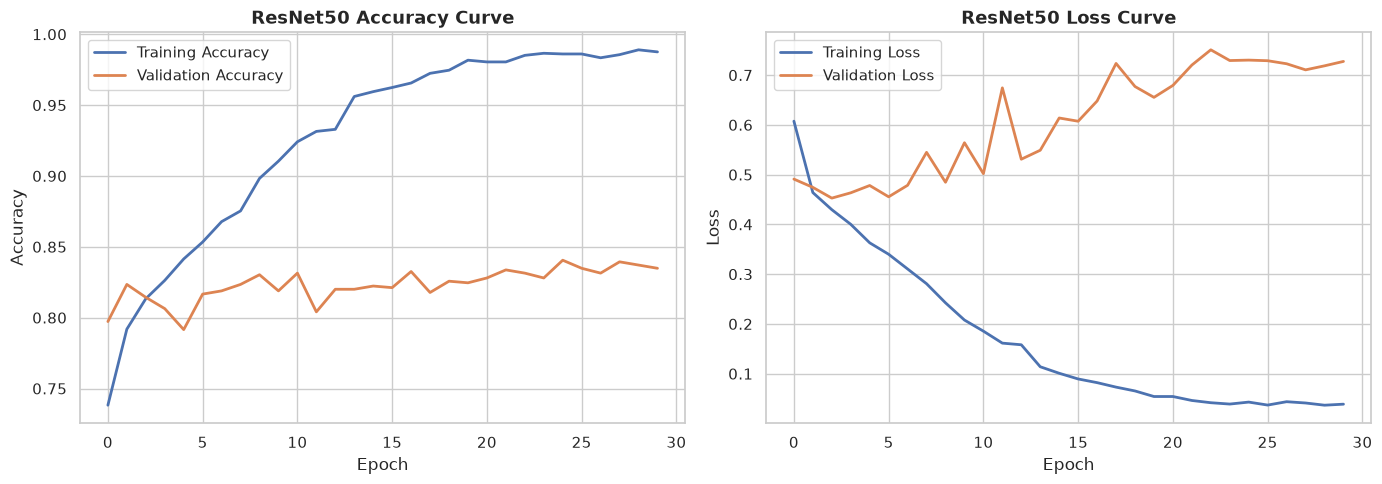

Cell 23 : Accuracy & Loss Curves Saved
----------------------------------------------------------------------
Saved To : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/figures/resnet50_accuracy_loss_curve.png


In [28]:
# ============================================================
# Cell 23: Training Accuracy & Loss Curves
# ============================================================

# -------------------------------
# Create Figure
# -------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ============================================================
# Accuracy Curve
# ============================================================

axes[0].plot(
    history_df["train_accuracy"],
    label="Training Accuracy",
    linewidth=2
)

axes[0].plot(
    history_df["valid_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

axes[0].set_title(
    f"{MODEL_NAME} Accuracy Curve",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# ============================================================
# Loss Curve
# ============================================================

axes[1].plot(
    history_df["train_loss"],
    label="Training Loss",
    linewidth=2
)

axes[1].plot(
    history_df["valid_loss"],
    label="Validation Loss",
    linewidth=2
)

axes[1].set_title(
    f"{MODEL_NAME} Loss Curve",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()

# -------------------------------
# Save Figure
# -------------------------------

ACCURACY_LOSS_CURVE_PATH = FIGURES_DIR / f"{MODEL_NAME.lower()}_accuracy_loss_curve.png"

plt.savefig(
    ACCURACY_LOSS_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# -------------------------------
# Display Information
# -------------------------------

print("=" * 70)
print("Cell 23 : Accuracy & Loss Curves Saved")
print("-" * 70)
print(f"Saved To : {ACCURACY_LOSS_CURVE_PATH}")
print("=" * 70)

## Training Accuracy and Loss Curves

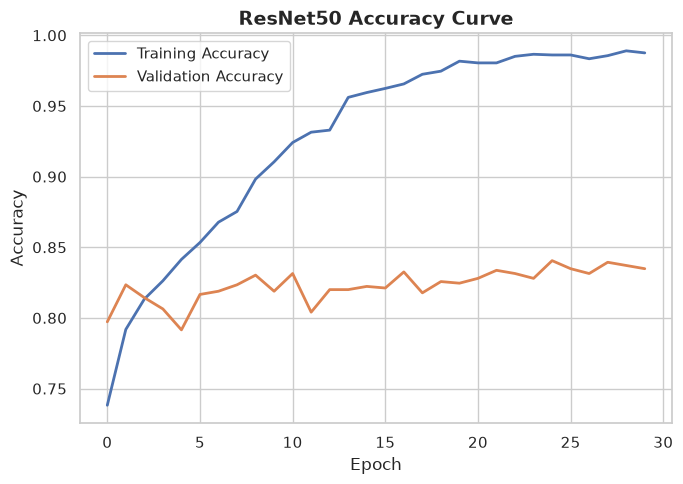

Cell 23 : Accuracy Curve Saved
----------------------------------------------------------------------
Saved To : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/figures/resnet50_accuracy_curve.png


In [29]:
# ============================================================
# Cell 23: Training Accuracy Curve
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    history_df["train_accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history_df["valid_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.title(
    f"{MODEL_NAME} Accuracy Curve",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    ACCURACY_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("Cell 23 : Accuracy Curve Saved")
print("-" * 70)
print(f"Saved To : {ACCURACY_CURVE_PATH}")
print("=" * 70)